In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
matches = pd.read_csv('../data/matches.csv')
deliveries = pd.read_csv('../data/deliveries.csv')

team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers': 'Sunrisers Hyderabad',
}
for col in ['team1','team2','winner','toss_winner']:
    matches[col] = matches[col].replace(team_name_map)
for col in ['batting_team','bowling_team']:
    deliveries[col] = deliveries[col].replace(team_name_map)

matches = matches.dropna(subset=['winner'])

sns.set_theme(style="darkgrid")

Chart 1 — Most Successful Teams

C:\Users\DELL\AppData\Local\Temp\ipykernel_17620\1843925190.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=team_wins, x='wins', y='team', palette='rocket')


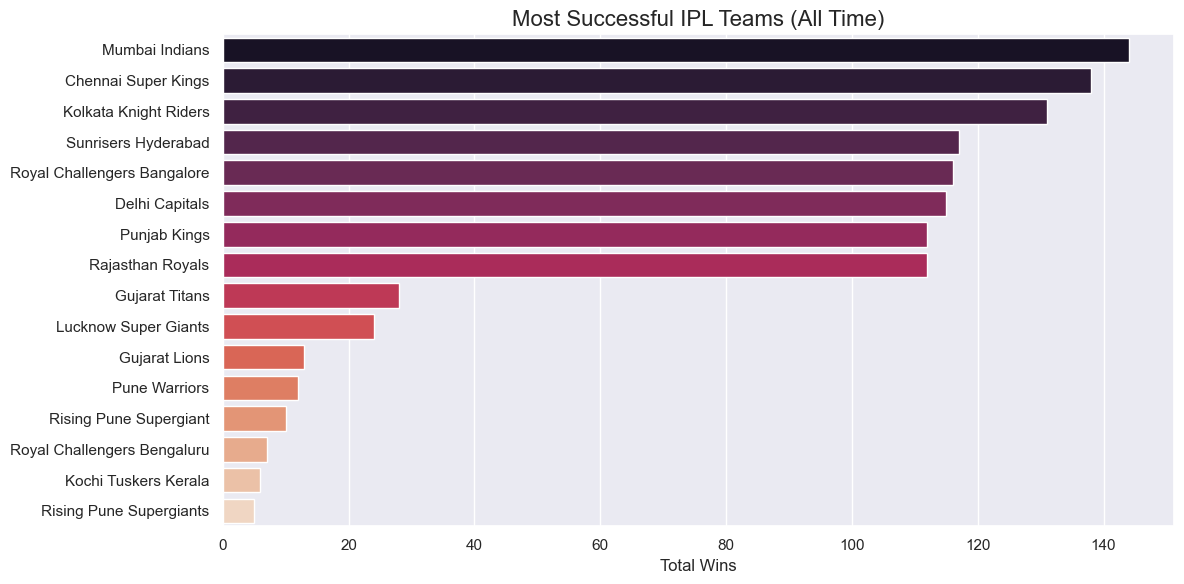

In [2]:
team_wins = matches['winner'].value_counts().reset_index()
team_wins.columns = ['team', 'wins']

plt.figure(figsize=(12, 6))
sns.barplot(data=team_wins, x='wins', y='team', palette='rocket')
plt.title('Most Successful IPL Teams (All Time)', fontsize=16)
plt.xlabel('Total Wins')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../data/chart1_team_wins.png')
plt.show()

Chart 2 — Top 10 Run Scorers

C:\Users\DELL\AppData\Local\Temp\ipykernel_17620\1438296595.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batters.values, y=top_batters.index, palette='mako')


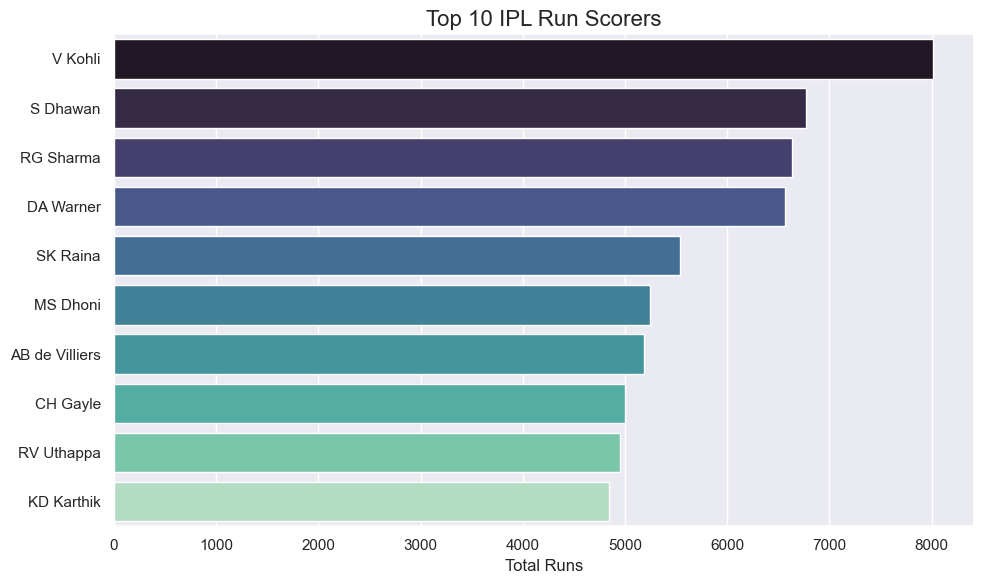

In [3]:
top_batters = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_batters.values, y=top_batters.index, palette='mako')
plt.title('Top 10 IPL Run Scorers', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../data/chart2_top_batters.png')
plt.show()

Chart 3 — Top 10 Wicket Takers

C:\Users\DELL\AppData\Local\Temp\ipykernel_17620\1189444346.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='flare')


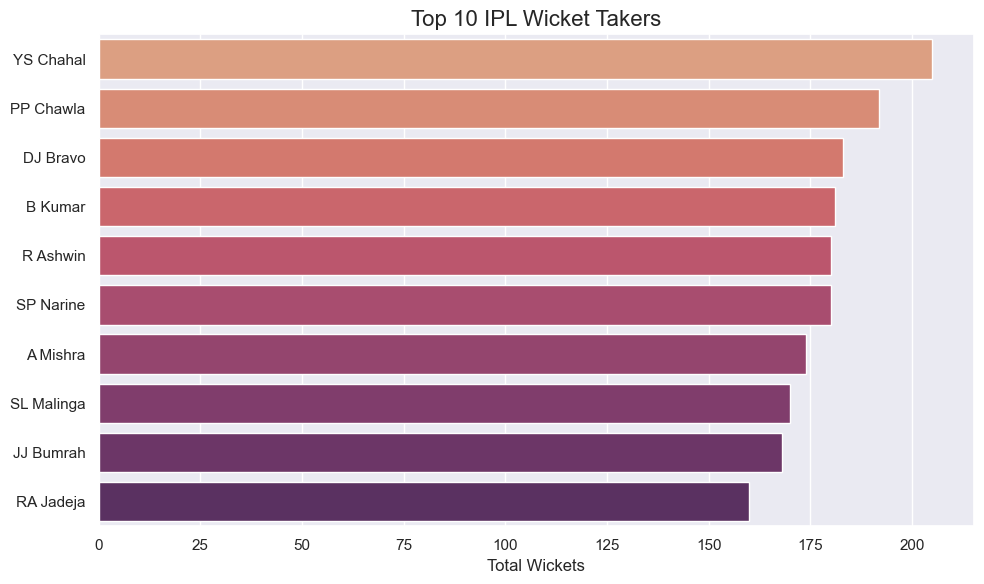

In [4]:
wickets = deliveries[deliveries['dismissal_kind'].notna() & 
                     ~deliveries['dismissal_kind'].isin(['run out', 'retired hurt', 'obstructing the field'])]
top_bowlers = wickets.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='flare')
plt.title('Top 10 IPL Wicket Takers', fontsize=16)
plt.xlabel('Total Wickets')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../data/chart3_top_bowlers.png')
plt.show()

Chart 4 — Toss Impact

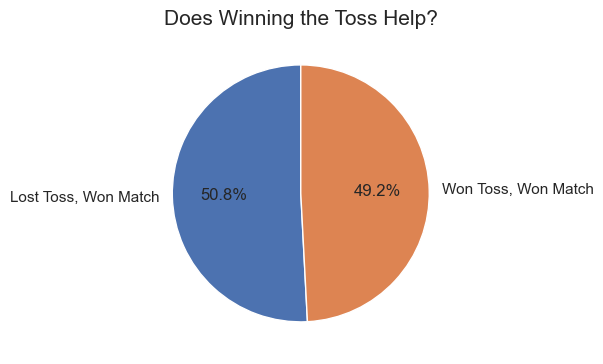

In [5]:
matches['toss_won_match'] = matches['toss_winner'] == matches['winner']
toss_impact = matches['toss_won_match'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(toss_impact, labels=['Lost Toss, Won Match', 'Won Toss, Won Match'],
        autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], startangle=90)
plt.title('Does Winning the Toss Help?', fontsize=15)
plt.tight_layout()
plt.savefig('../data/chart4_toss_impact.png')
plt.show()

Chart 5 — Best Venues by Average Score

C:\Users\DELL\AppData\Local\Temp\ipykernel_17620\4105784655.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_venue.values, y=avg_venue.index, palette='crest')


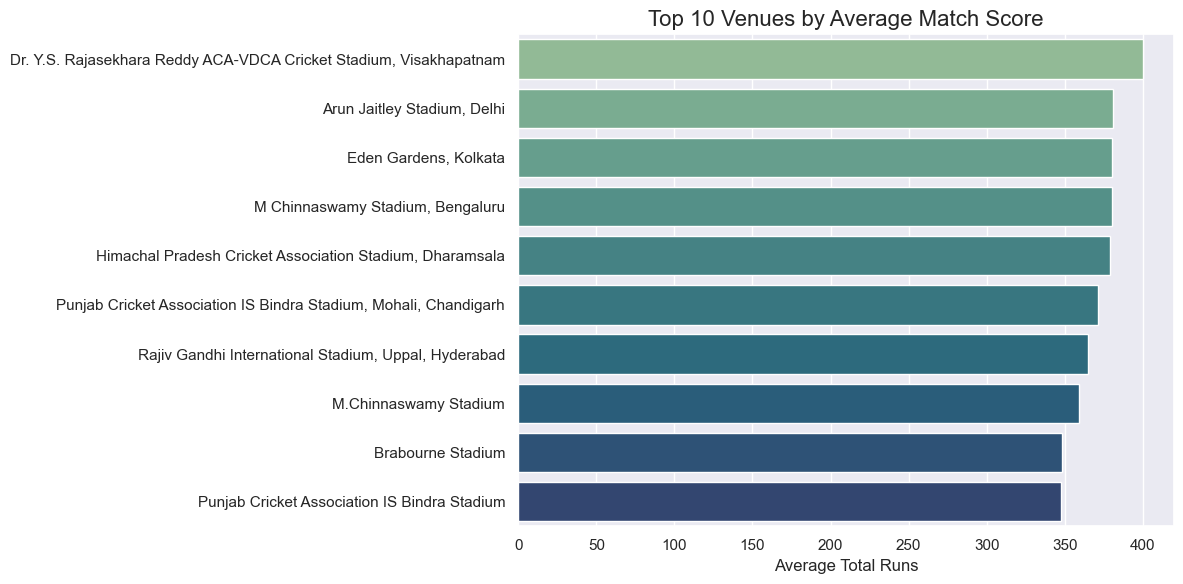

In [6]:
venue_scores = deliveries.groupby('match_id')['total_runs'].sum().reset_index()
venue_scores = venue_scores.merge(matches[['id','venue']], left_on='match_id', right_on='id')
avg_venue = venue_scores.groupby('venue')['total_runs'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_venue.values, y=avg_venue.index, palette='crest')
plt.title('Top 10 Venues by Average Match Score', fontsize=16)
plt.xlabel('Average Total Runs')
plt.ylabel('')
plt.tight_layout()
plt.savefig('../data/chart5_venues.png')
plt.show()

Chart 6 — Season-wise Run Trend

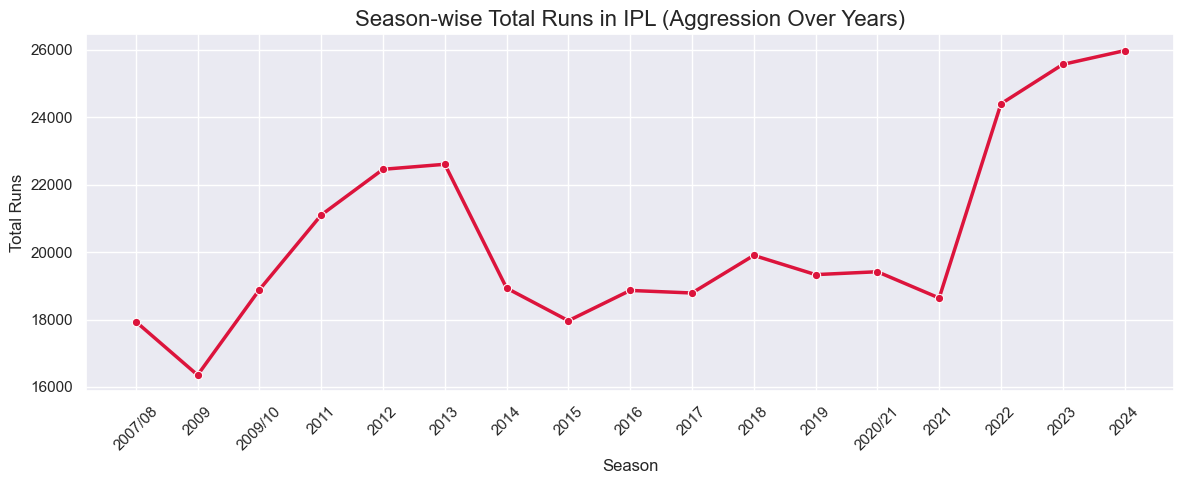

In [7]:
season_runs = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')
season_total = season_runs.groupby('season')['total_runs'].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=season_total, x='season', y='total_runs', marker='o', color='crimson', linewidth=2.5)
plt.title('Season-wise Total Runs in IPL (Aggression Over Years)', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/chart6_season_trend.png')
plt.show()